# 多径效应

> 本教程属于 OTFS 学习路径

---

## 1. 目标

在本教程结束时，你将掌握以下内容：

- 理解多径效应的成因和对信号的影响
- 理解码间干扰（ISI）与符号间干扰
- 为理解 OTFS 如何处理多径打下基础

---

## 2. 多径效应直观理解

在无线通信中，信号从发射机到接收机的传播并非只有一条路径。由于环境中物体的反射、散射和绕射，信号会经过多条不同路径到达接收机。

### 多径现象的核心特征

| 特征 | 描述 |
|------|------|
| **多径分量** | 信号通过多条路径到达，每条路径称为一个径 |
| **延迟差异** | 不同路径长度不同，导致各径到达时间不同 |
| **衰减差异** | 各径经历不同程度的路径损耗和反射损耗 |
| **相位差异** | 各径相位不同，叠加时产生建设性或破坏性干扰 |

### 造成多径的因素

- **建筑物反射**：信号在建筑表面反射后到达接收机
- **地面反射**：信号经地面反射形成另一条路径
- **移动体反射**：移动的车辆等物体对信号产生散射
- **大气折射**：大气层不均匀性导致信号折射

### 频率选择性衰落

由于各径相位不同，在某些频率上各径信号同相叠加（建设性干扰），信号增强；在另一些频率上反相叠加（破坏性干扰），信号衰减。这种现象称为**频率选择性衰落**。

```
发射信号 → → → → → → → → → → → 
              ↓                    ↓
          路径1(直达)         路径2(反射)
              ↓                    ↓
              └──────── + ────────┘
                       ↓
                   接收机叠加
```

---

## 3. 多径信道的数学模型

### 信道冲激响应

多径信道可以用**信道冲激响应（Channel Impulse Response, CIR）**来描述：

$$h(t) = \sum_{k=0}^{K-1} \alpha_k \delta(t - \tau_k)$$

其中：

- $K$：多径总数
- $\alpha_k$：第 $k$ 径的复数增益（幅度和相位）
- $\tau_k$：第 $k$ 径的延迟
- $\delta(t)$：Dirac delta 函数

### 延迟扩展（Delay Spread）

延迟扩展 $\sigma_\tau$ 定义为各径延迟的标准差，反映多径散布的时间范围：

$$\sigma_\tau = \sqrt{\frac{\sum_{k} \tau_k^2}{K} - \left(\frac{\sum_{k} \tau_k}{K}\right)^2}$$

最大延迟扩展 $\tau_{\max} = \max(\tau_k) - \min(\tau_k)$ 表示最晚到达径与最早到达径的时间差。

### 相干带宽（Coherence Bandwidth）

相干带宽 $B_c$ 是信道保持近似平坦的频率范围，与延迟扩展成反比：

$$B_c \approx \frac{1}{\sigma_\tau}$$

当信号带宽小于相干带宽时，信道表现为**平坦衰落**；当信号带宽大于相干带宽时，信道表现为**频率选择性衰落**。

### 频率响应

信道频率响应是冲激响应的傅里叶变换：

$$H(f) = \mathcal{F}\{h(t)\} = \sum_{k=0}^{K-1} \alpha_k e^{-j2\pi f \tau_k}$$

---

## 4. 代码演示：多径信道仿真

下面我们通过代码直观理解多径信道的特性。

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Simulation parameters
Fs = 10e6       # Sampling rate: 10 MHz
Ts = 1 / Fs     # Sampling period
duration = 10e-6  # Simulation duration: 10 us
t = np.arange(0, duration, Ts)

# Define multipath channel with 3 paths
# Path 1: alpha=1.0, tau=0 us (LOS - Line of Sight)
# Path 2: alpha=0.5∠(-45°), tau=1 us
# Path 3: alpha=0.3∠(-60°), tau=2 us
alpha = np.array([1.0, 0.5 * np.exp(-1j * np.pi / 4), 0.3 * np.exp(-1j * np.pi / 3)])  # Complex gains
tau_us = np.array([0, 1, 2])  # Delays in microseconds
tau = tau_us * 1e-6  # Convert to seconds

# Channel impulse response
h = np.zeros(len(t), dtype=complex)
for k in range(len(alpha)):
    idx = int(tau[k] / Ts)
    if idx < len(h):
        h[idx] = alpha[k]

print("Channel Impulse Response h(t) constructed.")
print(f"Number of paths: {len(alpha)}")
print(f"Delays (us): {tau_us}")
print(f"Complex gains: {alpha}")

Channel Impulse Response h(t) constructed.
Number of paths: 3
Delays (us): [0 1 2]
Complex gains: [1.        +0.j         0.35355339-0.35355339j 0.15      -0.25980762j]


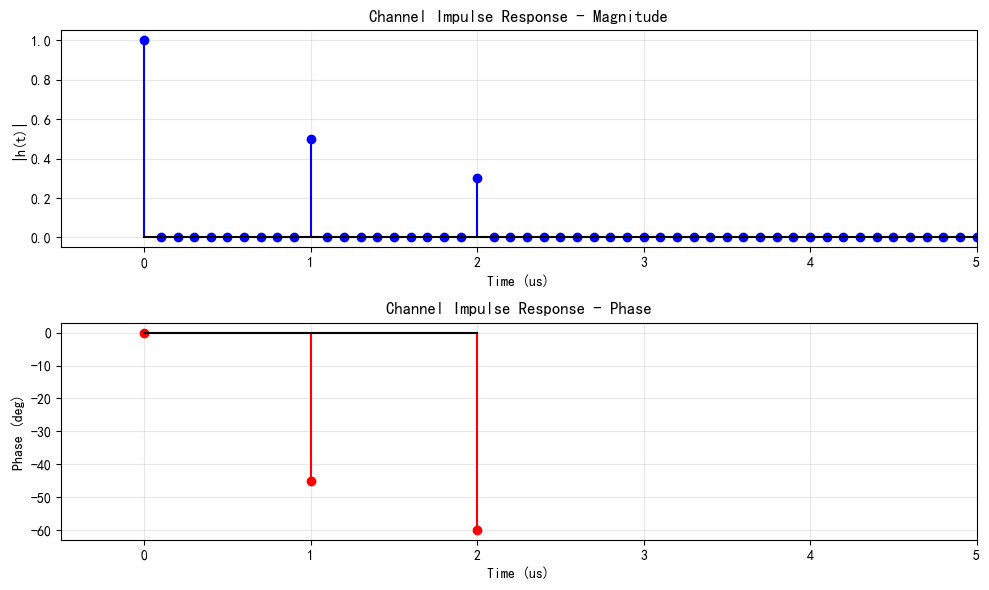

In [2]:
# Plot impulse response
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# Magnitude of impulse response
axes[0].stem(t * 1e6, np.abs(h), linefmt='b-', markerfmt='bo', basefmt='k-')
axes[0].set_xlabel('Time (us)')
axes[0].set_ylabel('|h(t)|')
axes[0].set_title('Channel Impulse Response - Magnitude')
axes[0].set_xlim(-0.5, 5)
axes[0].grid(True, alpha=0.3)

# Phase of impulse response (only non-zero samples)
nonzero_idx = np.where(np.abs(h) > 0)[0]
axes[1].stem(t[nonzero_idx] * 1e6, np.angle(h[nonzero_idx], deg=True), linefmt='r-', markerfmt='ro', basefmt='k-')
axes[1].set_xlabel('Time (us)')
axes[1].set_ylabel('Phase (deg)')
axes[1].set_title('Channel Impulse Response - Phase')
axes[1].set_xlim(-0.5, 5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

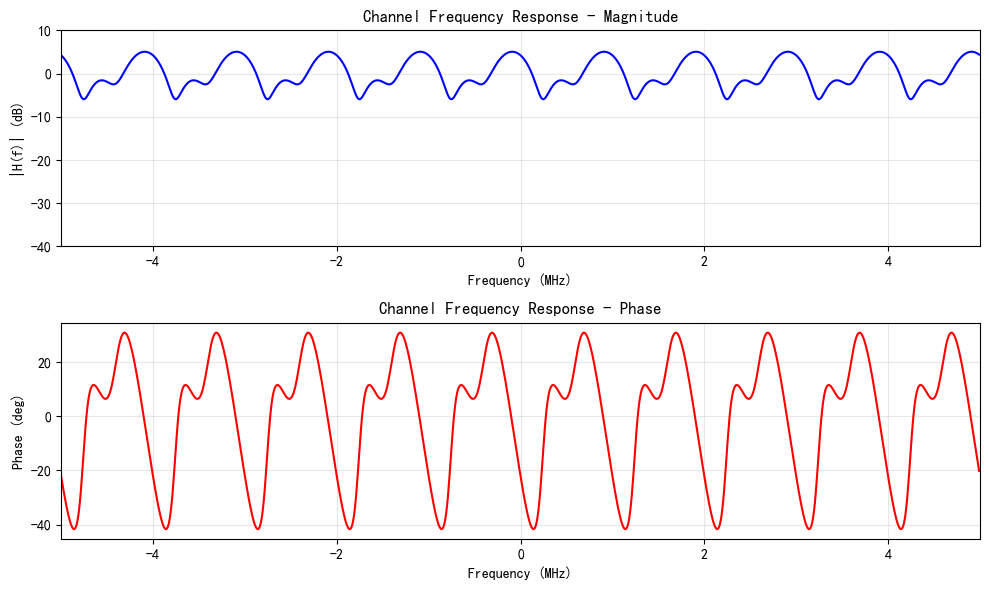


Frequency-selective fading observed: magnitude varies with frequency.


In [3]:
# Compute frequency response using FFT
NFFT = 1024
H = np.fft.fftshift(np.fft.fft(h, NFFT))
f = np.fft.fftfreq(NFFT, Ts)
f_shifted = np.fft.fftshift(f)

# Plot frequency response
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# Magnitude response (in dB)
axes[0].plot(f_shifted / 1e6, 20 * np.log10(np.abs(H) + 1e-12), 'b-', linewidth=1.5)
axes[0].set_xlabel('Frequency (MHz)')
axes[0].set_ylabel('|H(f)| (dB)')
axes[0].set_title('Channel Frequency Response - Magnitude')
axes[0].set_xlim(-5, 5)
axes[0].set_ylim(-40, 10)
axes[0].grid(True, alpha=0.3)

# Phase response
axes[1].plot(f_shifted / 1e6, np.angle(H, deg=True), 'r-', linewidth=1.5)
axes[1].set_xlabel('Frequency (MHz)')
axes[1].set_ylabel('Phase (deg)')
axes[1].set_title('Channel Frequency Response - Phase')
axes[1].set_xlim(-5, 5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFrequency-selective fading observed: magnitude varies with frequency.")

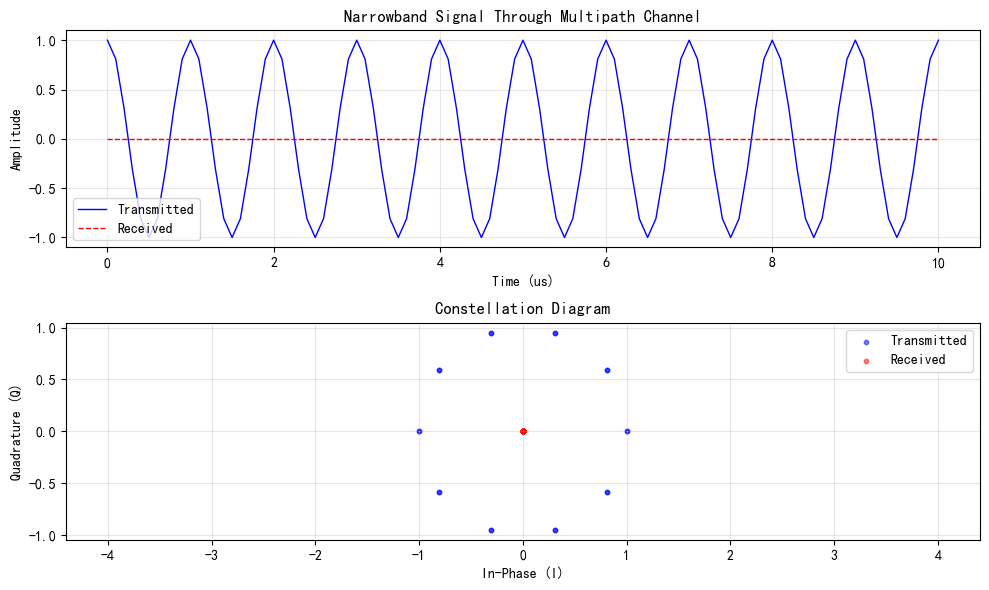


Observation: The received signal shows amplitude distortion due to multipath interference.


In [4]:
# Demonstrate frequency-selective fading with a narrowband signal
# Transmit a sinusoidal signal and observe the effect

# Signal parameters
f_signal = 1e6  # 1 MHz signal frequency
signal_t = np.exp(1j * 2 * np.pi * f_signal * t)

# Pass through channel (convolution)
received = np.convolve(h, signal_t, mode='same') * Ts

# Compare transmitted and received signals
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(t * 1e6, np.real(signal_t), 'b-', label='Transmitted', linewidth=1)
axes[0].plot(t * 1e6, np.real(received), 'r--', label='Received', linewidth=1)
axes[0].set_xlabel('Time (us)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Narrowband Signal Through Multipath Channel')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot constellation (received vs transmitted)
# Take a snapshot at time when signal is stable
snapshot_start = int(3e-6 / Ts)
snapshot_end = int(5e-6 / Ts)

axes[1].scatter(np.real(signal_t[snapshot_start:snapshot_end]), np.imag(signal_t[snapshot_start:snapshot_end]), 
               c='blue', alpha=0.5, s=10, label='Transmitted')
axes[1].scatter(np.real(received[snapshot_start:snapshot_end]), np.imag(received[snapshot_start:snapshot_end]), 
               c='red', alpha=0.5, s=10, label='Received')
axes[1].set_xlabel('In-Phase (I)')
axes[1].set_ylabel('Quadrature (Q)')
axes[1].set_title('Constellation Diagram')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axis('equal')

plt.tight_layout()
plt.show()

print("\nObservation: The received signal shows amplitude distortion due to multipath interference.")

---

## 5. 码间干扰（ISI）与均衡

### 什么是码间干扰

当多径延迟扩展大于符号周期时，相邻符号的信号会叠加在当前符号上，造成**码间干扰（Inter-Symbol Interference, ISI）**。这会导致符号判决出错，系统性能下降。

```
符号周期 Ts
    │←──────→│
    │         │
  Symbol 1   Symbol 2   Symbol 3
  ───────   ───────   ───────
    ↖       ↗
      ↖   ↗  ↖     ← 多径造成符号重叠
        ↖↗
      (ISI)
```

### 循环前缀（Cyclic Prefix, CP）

OFDM 系统通过添加循环前缀来对抗 ISI：

1. 将符号尾部的一段复制到头部作为保护间隔
2. 只要 CP 长度大于最大延迟扩展，各径叠加仍保持循环性
3. 接收机通过移除 CP 消除符号间干扰

**CP 的作用**：

- 将线性卷积转换为循环卷积
- 吸收多径延迟，避免符号间干扰
- 代价是系统吞吐率略有下降（CP overhead）

### 均衡器的基本概念

均衡器是用于补偿信道失真的装置或算法。在单载波系统中，均衡器通常设计为信道的逆滤波器：

$$h_{eq} * h \approx \delta$$

常见均衡器类型：

| 类型 | 描述 |
|------|------|
| **线性均衡器** | 简单的 FIR 滤波器，直接求逆 |
| **判决反馈均衡器（DFE）** | 利用先前符号判决结果减少 ISI |
| **最大似然序列估计（MLSE）** | 寻找最可能的发送序列（最优但复杂）|

---

## 6. 关联 OTFS

### OFDM 与多径挑战

OFDM（正交频分复用）通过将宽带信号分成多个窄带子载波来对抗频率选择性衰落：

- 每个子载波经历平坦衰落（而非频率选择性）
- 通过添加循环前缀（CP）来对抗 ISI
- 接收机对每个子载波进行简单的一tap 均衡

**但 OFDM 仍面临挑战**：

- 高速移动场景下，多普勒扩展导致子载波正交性丧失
- 高频段（如毫米波）信道变化快，CP 可能不够长
- 所有径叠加在一起，每径独立特性被混合

### OTFS 的解决思路

OTFS（正交时频空）是一种新型调制方案，它在**延迟-多普勒域**而不是时频域进行信号处理：

| 特性 | OFDM | OTFS |
|------|------|------|
| **处理域** | 时频域 | 延迟-多普勒域 |
| **信道表示** | 频率响应 H(f) | 冲激响应 h(τ, ν) |
| **多径处理** | 所有径叠加后均衡 | 各径在延迟域分离 |
| **移动性** | 高多普勒敏感 | 对多普勒天然鲁棒 |

### OTFS 的核心优势

1. **延迟-多普勒域表示**：将信道表示为延迟-多普勒域的二维冲激响应，每径独立表征

2. **各径独立处理**：每条多径被视为独立的点，叠加不再是问题

3. **时不变等价信道**：经过变换后，OTFS 等效于时不变信道，所有子载波共享相同信道

```
OFDM:    多径叠加 → 频率选择性衰落 → 复杂均衡
OTFS:    多径分离 → 延迟域独立处理 → 简单均衡
```

这使得 OTFS 在高移动性、高频段场景下比 OFDM 具有显著优势。

---

## 7. 思考题

1. **多径效应**：如果从发射机到接收机有两条路径，一条直射，一条经过建筑物反射且路径长度多 300 米，则两条路径的时间差是多少？（光速约为 3×10⁸ m/s）

2. **频率选择性衰落**：为什么低频信号（如传统 FM 广播）在城市多径环境中通常比高频信号（如 5GHz WiFi）更稳定？

3. **循环前缀设计**：某系统符号周期为 100μs，最大多径延迟为 20μs，则 CP 长度至少需要多少才能避免 ISI？如果系统要求 10% 的 CP 开销，这个系统还能满足要求吗？

4. **OTFS vs OFDM**：解释为什么在延迟-多普勒域处理多径信道可以让各径独立处理，而不需要处理衰落叠加问题。

5. **实际应用**：在车联网（V2X）通信中，车辆高速移动导致信道快速变化。请分析多普勒扩展对 OFDM 和 OTFS 的不同影响，以及为什么 OTFS 更适合高移动性场景。

In [5]:
# Solutions hint (for reference)
print("=" * 60)
print("思考题参考解答提示")
print("=" * 60)

# Q1: Path difference of 300m
c = 3e8  # speed of light
path_diff = 300  # meters
time_diff = path_diff / c  # seconds
print(f"\n第1题：时间差 = {path_diff}m / {c:.0e}m/s = {time_diff*1e9:.2f} ns")

# Q3: CP length calculation
symbol_period = 100e-6  # 100 us
max_delay = 20e-6  # 20 us
cp_min = max_delay  # minimum CP length
cp_overhead = cp_min / symbol_period
print(f"\n第3题：")
print(f"  - 最小CP长度 = {max_delay*1e6:.0f} us")
print(f"  - CP开销 = {cp_overhead*100:.1f}%")
print(f"  - 10%开销要求下，最大可容忍延迟 = {0.1 * symbol_period*1e6:.0f} us")
print(f"  - 该系统({'能' if max_delay <= 0.1 * symbol_period else '不能'})满足10% CP开销要求")

思考题参考解答提示

第1题：时间差 = 300m / 3e+08m/s = 1000.00 ns

第3题：
  - 最小CP长度 = 20 us
  - CP开销 = 20.0%
  - 10%开销要求下，最大可容忍延迟 = 10 us
  - 该系统(不能)满足10% CP开销要求
